<a href="https://colab.research.google.com/github/OPthyago/TECH-CHALLENGE-FASE-1/blob/andre/notebooks/TechChallenge_Revisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge - Análise Exploratória de Dados com Foco em NPS

Esta análise exploratória tem como objetivo identificar fatores associados à satisfação dos clientes, medida pelo NPS.

O foco não é apenas descrever os dados, mas entender quais aspectos da experiência de compra, entrega e atendimento diferenciam clientes detratores, neutros e promotores.

A análise busca responder perguntas de negócio como:

- Quais fatores parecem mais críticos para a satisfação?
- O que mais gera detratores?
- Existe algum ponto de ruptura na experiência do cliente?
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

## 1. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas utilizadas para manipulação dos dados e criação dos gráficos.

In [1]:
# Libs - Exploração e Manipulação de dados
import pandas as pd

# Libs Graficas
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carregamento da base de dados

A base utilizada contém informações de clientes, pedidos, entrega, atendimento e satisfação.

A variável principal da análise é `nps_score`, que representa a nota de satisfação do cliente.

In [18]:
df = pd.read_csv("data/desafio_nps_fase_1.csv")

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 3. Dicionário de dados resumido



Abaixo estão as principais variáveis da base para a análise de NPS:

| Variável | Descrição |
|---|---|
| `customer_id` | Identificador do cliente |
| `customer_age` | Idade do cliente |
| `customer_region` | Região do cliente |
| `customer_tenure_months` | Tempo de relacionamento do cliente em meses |
| `order_id` | Identificador do pedido |
| `order_value` | Valor do pedido |
| `discount_value` | Valor de desconto |
| `delivery_time_days` | Tempo de entrega em dias |
| `delivery_delay_days` | Dias de atraso na entrega |
| `freight_value` | Valor do frete |
| `delivery_attempts` | Quantidade de tentativas de entrega |
| `customer_service_contacts` | Quantidade de contatos com atendimento |
| `resolution_time_days` | Tempo de resolução em dias |
| `nps_score` | Nota de NPS dada pelo cliente |
| `repeat_purchase_30d` | Indica se houve recompra em até 30 dias |
| `complaints_count` | Quantidade de reclamações |
| `csat_internal_score` | Nota interna de satisfação |

As colunas `customer_id` e `order_id` são identificadores. Elas ajudam a localizar clientes e pedidos, mas não devem ser interpretadas como fatores explicativos da satisfação.

## 4. Visão geral e qualidade dos dados

Antes de analisar o NPS, é importante verificar se os dados estão adequados para análise.

Nesta etapa, observamos:

- quantidade de linhas e colunas;
- nomes das colunas;
- tipos de dados;
- valores ausentes;
- duplicidades;
- possíveis inconsistências.

In [19]:
# Quantidade de linhas e colunas
linhas, colunas = df.shape

print("Quantidade de linhas:", linhas)
print("Quantidade de colunas:", colunas)

Quantidade de linhas: 2500
Quantidade de colunas: 19


In [20]:
# Nomes das colunas
list(df.columns)

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

In [21]:
# Tipos de dados e valores não nulos
# Essa visualização ajuda a verificar se as variáveis estão nos formatos esperados.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [22]:
# Valores ausentes por coluna
valores_ausentes = df.isnull().sum().sort_values(ascending=False)
valores_ausentes

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [23]:
# Percentual de valores ausentes por coluna
percentual_ausente = (df.isnull().mean() * 100).sort_values(ascending=False)
percentual_ausente

,0
customer_id,0.0
customer_age,0.0
customer_region,0.0
customer_tenure_months,0.0
order_id,0.0
order_value,0.0
items_quantity,0.0
discount_value,0.0
payment_installments,0.0
delivery_time_days,0.0


In [24]:
# Verificando linhas totalmente duplicadas
linhas_duplicadas = df.duplicated().sum()

print("Quantidade de linhas duplicadas:", linhas_duplicadas)

Quantidade de linhas duplicadas: 0


In [25]:
# Verificando se existem pedidos duplicados
pedidos_duplicados = df["order_id"].duplicated().sum()

print("Quantidade de order_id duplicados:", pedidos_duplicados)

Quantidade de order_id duplicados: 0


### Comentário sobre qualidade dos dados

A base possui 2.500 registros e 19 colunas. Não foram identificados valores ausentes nem duplicidades completas.

Também foi verificado se existiam pedidos duplicados por `order_id`. Como `order_id` é um identificador de pedido, duplicidades nessa coluna poderiam indicar problema na base.

Nesta análise, as variáveis `customer_id` e `order_id` serão tratadas apenas como identificadores, não como explicações para o NPS.

## 5. Estatística descritiva inicial

A estatística descritiva ajuda a entender a distribuição geral das variáveis numéricas.

Nesta etapa, observamos média, mediana, mínimo, máximo, quartis e desvio padrão.

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.500000,721.832160,1.00,625.7500,1250.500,1875.2500,2500.00
customer_age,2500.0,43.396000,14.888487,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_id,2500.0,51250.500000,721.832160,50001.00,50625.7500,51250.500,51875.2500,52500.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00


### Sobre a estatística descritiva

A estatística descritiva mostra que a base contém variáveis ligadas a cliente, pedido, entrega, atendimento e satisfação.

Para esta análise, o foco será concentrado principalmente nas variáveis que podem estar associadas à experiência do cliente:

- nps_score;
- delivery_delay_days;
- complaints_count;
- customer_service_contacts;
- resolution_time_days;
- csat_internal_score;
- repeat_purchase_30d.

## 6. Visão geral do NPS

Nesta etapa, analisamos a variável principal do estudo: `nps_score`.

É importante diferenciar duas coisas:

- **média da nota de NPS**: média das notas de 0 a 10;
- **NPS clássico de negócio**: percentual de promotores menos percentual de detratores.

In [27]:
# Estatísticas da nota de NPS
df["nps_score"].describe()

,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


In [28]:
print("Média da nota de NPS:", df["nps_score"].mean())
print("Mediana da nota de NPS:", df["nps_score"].median())
print("Menor nota de NPS:", df["nps_score"].min())
print("Maior nota de NPS:", df["nps_score"].max())
print("Desvio padrão do NPS:", df["nps_score"].std())

Média da nota de NPS: 4.3786
Mediana da nota de NPS: 4.4
Menor nota de NPS: 0.0
Maior nota de NPS: 10.0
Desvio padrão do NPS: 2.5102291808152013


### Classificação dos clientes em grupos de NPS

Os clientes foram classificados de acordo com a regra tradicional do NPS:

- **Detratores**: notas de 0 a 6;
- **Neutros**: notas 7 e 8;
- **Promotores**: notas 9 e 10.

In [29]:
def classificar_nps(nota):
    if nota <= 6:
        return "Detrator"
    elif nota <= 8:
        return "Neutro"
    else:
        return "Promotor"

# Criando a coluna com o grupo de NPS
df["grupo_nps"] = df["nps_score"].apply(classificar_nps)

# Ordem desejada para os gráficos e tabelas
ordem_nps = ["Detrator", "Neutro", "Promotor"]

df[["nps_score", "grupo_nps"]].head()

,nps_score,grupo_nps
0,6.9,Neutro
1,2.4,Detrator
2,4.8,Detrator
3,5.9,Detrator
4,6.1,Neutro


In [30]:
# Quantidade de clientes por grupo de NPS
qtd_grupos = df["grupo_nps"].value_counts().reindex(ordem_nps)
qtd_grupos

,count
grupo_nps,
Detrator,1851
Neutro,448
Promotor,201


In [31]:
# Percentual de clientes por grupo de NPS
percentual_grupos = df["grupo_nps"].value_counts(normalize=True).reindex(ordem_nps) * 100
percentual_grupos

,proportion
grupo_nps,
Detrator,74.04
Neutro,17.92
Promotor,8.04


In [32]:
# Cálculo do NPS clássico
promotores = percentual_grupos["Promotor"]
detratores = percentual_grupos["Detrator"]

nps_geral = promotores - detratores

print("Percentual de promotores:", promotores)
print("Percentual de detratores:", detratores)
print("NPS geral:", nps_geral)

Percentual de promotores: 8.04
Percentual de detratores: 74.03999999999999
NPS geral: -66.0


### Interpretação inicial do NPS

A média da nota de NPS é aproximadamente **4,38**, o que indica uma avaliação baixa na escala de 0 a 10.

O NPS clássico da base é aproximadamente **-66**, pois existe uma proporção muito maior de detratores do que de promotores.

Esse resultado mostra um cenário crítico de satisfação e justifica uma análise mais profunda dos fatores associados à experiência do cliente.

## 7. Análise gráfica da distribuição do NPS

Os gráficos abaixo ajudam a visualizar a concentração das notas e a composição dos grupos de NPS.

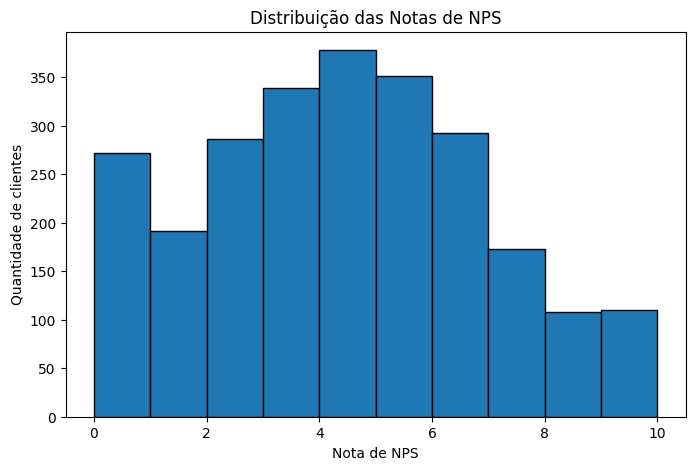

In [33]:
plt.figure(figsize=(8, 5))

plt.hist(df["nps_score"], bins=10, edgecolor="black")

plt.title("Distribuição das Notas de NPS")
plt.xlabel("Nota de NPS")
plt.ylabel("Quantidade de clientes")
plt.show()

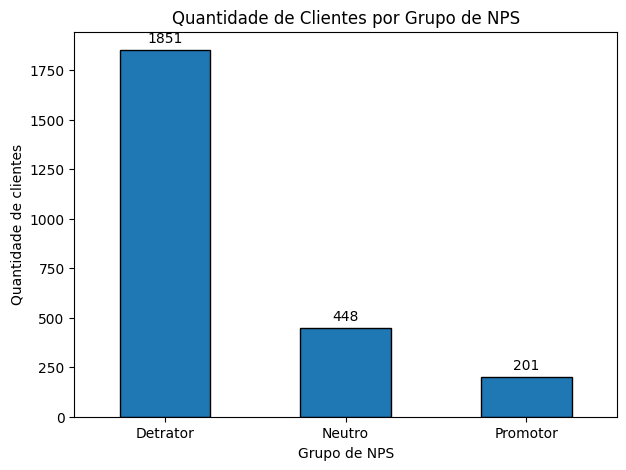

In [35]:
plt.figure(figsize=(7, 5))

ax = qtd_grupos.plot(kind="bar", edgecolor="black")

plt.title("Quantidade de Clientes por Grupo de NPS")
plt.xlabel("Grupo de NPS")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], padding=3)

plt.show()

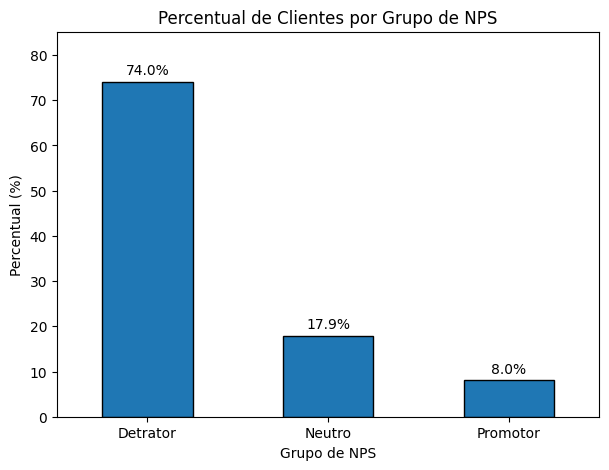

In [37]:
plt.figure(figsize=(7, 5))

ax = percentual_grupos.plot(kind="bar", edgecolor="black")

plt.title("Percentual de Clientes por Grupo de NPS")
plt.xlabel("Grupo de NPS")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.ylim(0, percentual_grupos.max() * 1.15)

plt.show()

### Interpretação dos gráficos de NPS

Os gráficos mostram que a base possui predominância de clientes detratores. Isso explica o NPS geral negativo.

A empresa possui, portanto, uma oportunidade importante de melhoria na experiência do cliente, principalmente porque o grupo de promotores representa uma parcela pequena da base.

## 8. Quais fatores parecem mais críticos para a satisfação?

Para responder essa pergunta, primeiro analisamos a correlação entre as variáveis numéricas e o `nps_score`.

A correlação varia entre -1 e +1:

- valores próximos de **+1** indicam associação positiva;
- valores próximos de **-1** indicam associação negativa;
- valores próximos de **0** indicam baixa relação linear.

Importante: correlação não significa causalidade. A análise indica associação, não prova causa direta.

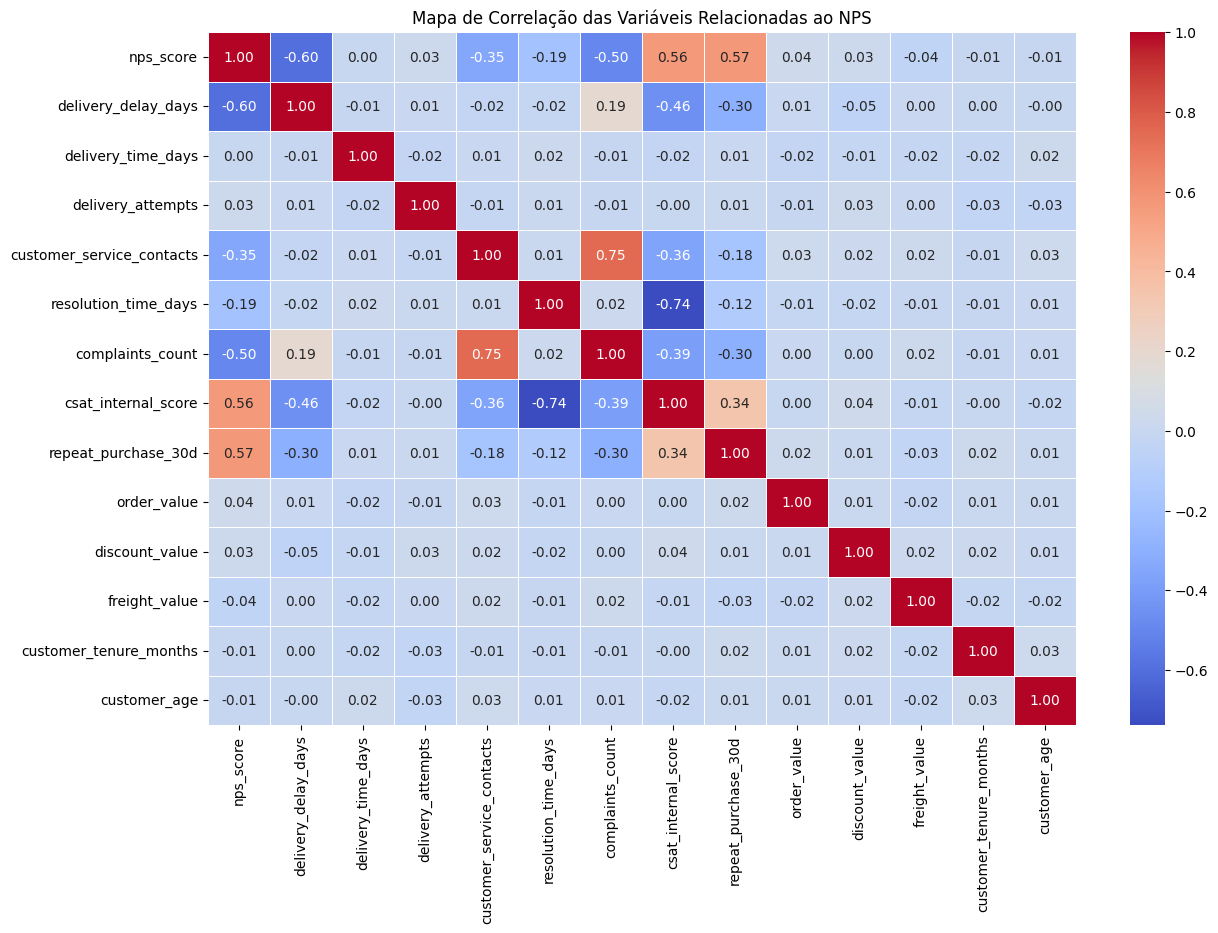

In [38]:
# Selecionando variáveis relevantes para a análise de correlação
# customer_id e order_id foram removidos porque são identificadores.
colunas_correlacao = [
    "nps_score",
    "delivery_delay_days",
    "delivery_time_days",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",
    "csat_internal_score",
    "repeat_purchase_30d",
    "order_value",
    "discount_value",
    "freight_value",
    "customer_tenure_months",
    "customer_age"
]

correlacao = df[colunas_correlacao].corr()

plt.figure(figsize=(14, 9))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de Correlação das Variáveis Relacionadas ao NPS")
plt.show()

In [39]:
# Correlação de cada variável com o NPS, ordenada da menor para a maior
correlacoes_nps = correlacao["nps_score"].drop("nps_score").sort_values()
correlacoes_nps

,nps_score
delivery_delay_days,-0.597260
complaints_count,-0.496800
customer_service_contacts,-0.350845
resolution_time_days,-0.191392
freight_value,-0.041087
customer_age,-0.009936
customer_tenure_months,-0.009711
delivery_time_days,0.000925
discount_value,0.025104
delivery_attempts,0.027680


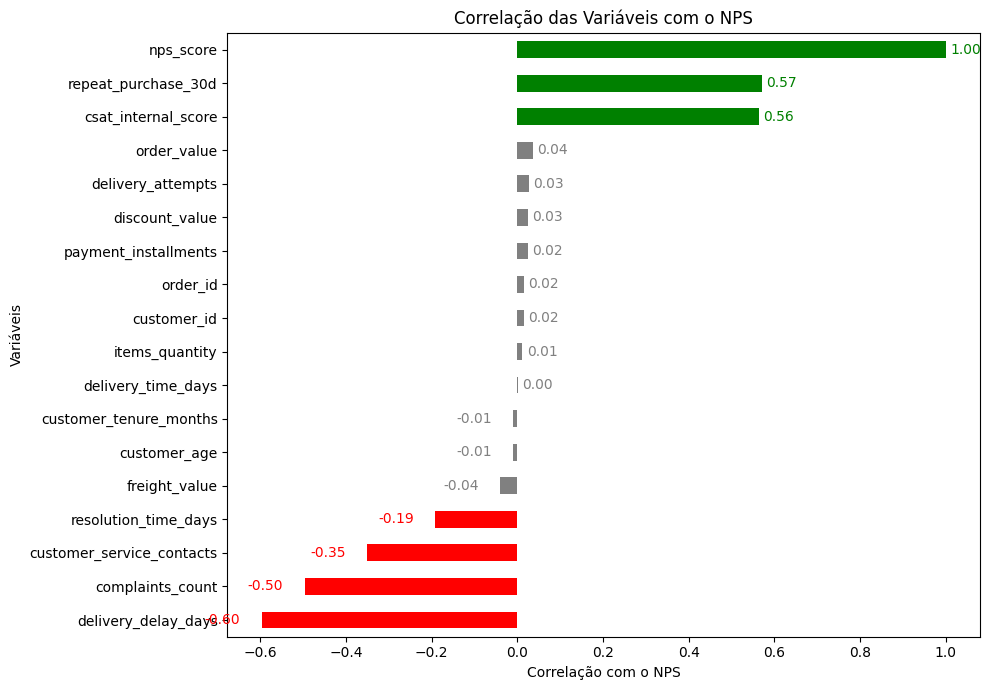

In [40]:
# Filtrar as correlações voltadas apenas ao NPS
correlacoes_nps = df.corr(numeric_only=True)["nps_score"].sort_values()

# Define as cores das barras:
# verde: correlação >= 0.1
# vermelho: correlação <= -0.1
# cinza: entre -0.1 e 0.1
cores = [
    "green" if valor >= 0.1 else "red" if valor <= -0.1 else "gray"
    for valor in correlacoes_nps
]

plt.figure(figsize=(10, 7))

ax = correlacoes_nps.plot(
    kind="barh",
    color=cores
)

# Adiciona os rótulos em cada barra
for barra in ax.patches:
    largura = barra.get_width()

    # Define a cor do rótulo seguindo a mesma regra das barras
    cor = "green" if largura >= 0.1 else "red" if largura <= -0.1 else "gray"

    deslocamento = 0.01 if largura >= 0 else -0.05
    alinhamento = "left" if largura >= 0 else "right"

    ax.text(
        largura + deslocamento,
        barra.get_y() + barra.get_height() / 2,
        f"{largura:.2f}",
        va="center",
        ha=alinhamento,
        fontsize=10,
        color=cor
    )

plt.title("Correlação das Variáveis com o NPS")
plt.xlabel("Correlação com o NPS")
plt.ylabel("Variáveis")

plt.tight_layout()
plt.show()

### Resposta de negócio

Os fatores que parecem mais críticos para a satisfação estão ligados principalmente à **experiência pós-compra**.

As variáveis com maior associação negativa com o NPS são:

- atraso na entrega (`delivery_delay_days`);
- quantidade de reclamações (`complaints_count`);
- contatos com atendimento (`customer_service_contacts`);
- tempo de resolução (`resolution_time_days`).

Já as variáveis com associação positiva mais forte são:

- CSAT interno (`csat_internal_score`);
- recompra em 30 dias (`repeat_purchase_30d`).

Isso sugere que clientes com menos problemas de entrega, menos reclamações, menos necessidade de atendimento e melhor avaliação interna tendem a apresentar maior NPS.

## 9. O que mais gera detratores?

Para entender o que diferencia os detratores dos demais clientes, comparamos indicadores médios entre os grupos de NPS.

Nesta seção, os gráficos foram separados para evitar misturar variáveis com escalas diferentes no mesmo eixo.

In [41]:
# Criando uma tabela com médias por grupo de NPS
indicadores_experiencia = [
    "delivery_delay_days",
    "complaints_count",
    "customer_service_contacts",
    "resolution_time_days",
    "csat_internal_score",
    "repeat_purchase_30d"
]

media_por_grupo = df.groupby("grupo_nps")[indicadores_experiencia].mean().reindex(ordem_nps)
media_por_grupo

,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days,csat_internal_score,repeat_purchase_30d
grupo_nps,,,,,,
Detrator,2.534306,4.622907,1.694219,5.793625,2.340465,0.000000
Neutro,1.395089,2.986607,1.129464,4.832589,4.230357,0.037946
Promotor,0.756219,2.393035,0.781095,4.104478,5.604975,1.000000


### 9.1 Atraso médio na entrega por grupo de NPS

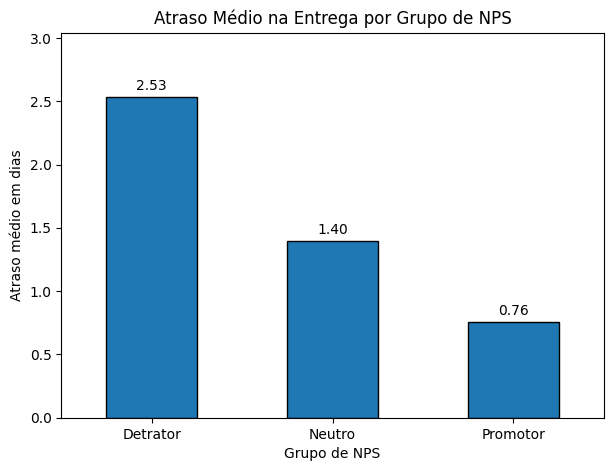

In [43]:
atraso_por_grupo = df.groupby("grupo_nps")["delivery_delay_days"].mean().reindex(ordem_nps)

plt.figure(figsize=(7, 5))
ax = atraso_por_grupo.plot(kind="bar", edgecolor="black")

plt.title("Atraso Médio na Entrega por Grupo de NPS")
plt.xlabel("Grupo de NPS")
plt.ylabel("Atraso médio em dias")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.ylim(0, atraso_por_grupo.max() * 1.2)

plt.show()

Os detratores apresentam maior atraso médio na entrega. Esse resultado sugere que problemas logísticos estão fortemente associados à baixa satisfação.

## 10. Existe algum ponto de ruptura na experiência do cliente?

Nesta etapa, buscamos identificar limites a partir dos quais a experiência do cliente se deteriora de forma mais intensa.

Foram analisados dois possíveis pontos de ruptura:

- dias de atraso na entrega;
- quantidade de reclamações.

In [48]:
# Criando uma coluna para indicar se o cliente é detrator
df["eh_detrator"] = df["grupo_nps"] == "Detrator"

# Taxa de detratores por dias de atraso
taxa_detratores_atraso = df.groupby("delivery_delay_days")["eh_detrator"].mean() * 100

taxa_detratores_atraso

,eh_detrator
delivery_delay_days,
0,36.462094
1,59.674797
2,75.386997
3,89.714286
4,95.925926
5,99.137931
6,100.000000
7,100.000000
8,100.000000


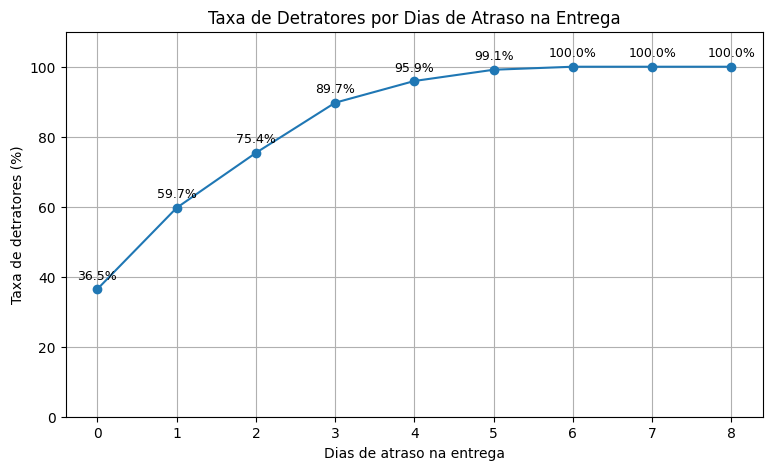

In [50]:
plt.figure(figsize=(9, 5))

ax = taxa_detratores_atraso.plot(kind="line", marker="o")

plt.title("Taxa de Detratores por Dias de Atraso na Entrega")
plt.xlabel("Dias de atraso na entrega")
plt.ylabel("Taxa de detratores (%)")
plt.grid(True)
plt.ylim(0, 110)

# Adicionando rótulos nos pontos
for x, y in zip(taxa_detratores_atraso.index, taxa_detratores_atraso.values):
    plt.text(
        x,
        y + 2,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

### Interpretação do ponto de ruptura por atraso

A taxa de detratores cresce rapidamente conforme o atraso aumenta.

Sem atraso, a taxa de detratores já é relevante. Porém, com 1 dia de atraso, a proporção sobe bastante. A partir de 2 dias, mais de 75% dos clientes são detratores. Com 3 dias, essa taxa se aproxima de 90%.

Isso sugere um ponto de ruptura entre **2 e 3 dias de atraso**.

In [51]:
# Criando uma coluna para indicar se o cliente é detrator
df["eh_detrator"] = df["grupo_nps"] == "Detrator"

# Taxa de detratores por quantidade de reclamações
taxa_detratores_reclamacoes = df.groupby("complaints_count")["eh_detrator"].mean() * 100

taxa_detratores_reclamacoes

,eh_detrator
complaints_count,
0,4.347826
1,8.196721
2,43.321300
3,67.652860
4,81.166667
5,88.288288
6,93.609023
7,93.491124
8,100.000000


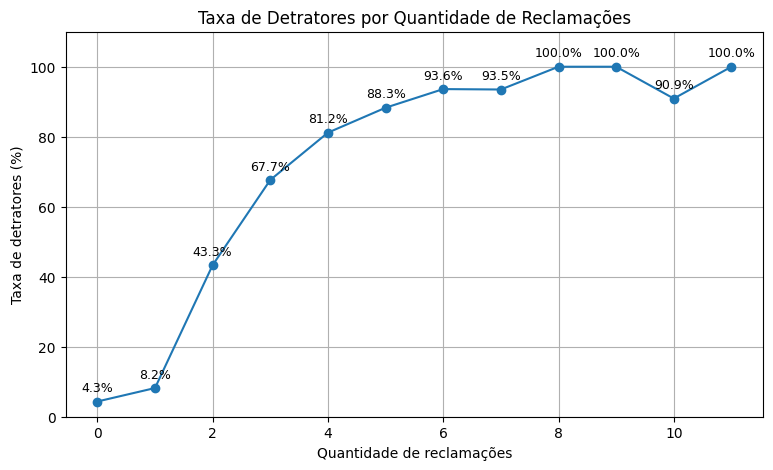

In [52]:
plt.figure(figsize=(9, 5))

ax = taxa_detratores_reclamacoes.plot(kind="line", marker="o")

plt.title("Taxa de Detratores por Quantidade de Reclamações")
plt.xlabel("Quantidade de reclamações")
plt.ylabel("Taxa de detratores (%)")
plt.grid(True)
plt.ylim(0, 110)

# Adicionando rótulos nos pontos
for x, y in zip(taxa_detratores_reclamacoes.index, taxa_detratores_reclamacoes.values):
    plt.text(
        x,
        y + 2,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

### Interpretação do ponto de ruptura por reclamações

A taxa de detratores é baixa quando o cliente possui 0 ou 1 reclamação.

A partir de 2 reclamações, a taxa cresce de forma importante. Com 3 reclamações, a maioria dos clientes já é detratora. Com 4 reclamações, a taxa ultrapassa 80%.

Esse comportamento sugere um ponto de ruptura em torno de **3 reclamações**.

### Conclusão sobre ponto de ruptura

A análise sugere dois pontos críticos:

- atraso a partir de **2 a 3 dias**;
- acúmulo de **3 ou mais reclamações**.

Esses limites podem ser usados como alertas operacionais. Clientes próximos desses patamares poderiam ser priorizados por ações preventivas, como contato proativo, acompanhamento da entrega ou tratativa especial no atendimento.

## 11. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

Nesta etapa, analisamos segmentos de clientes para entender se existe diferença no NPS médio por perfil.

Foram analisados:

- recompra em 30 dias;
- região;
- faixa etária;
- tempo de relacionamento.

Sempre que possível, também observamos a quantidade de clientes em cada segmento, pois médias com poucos registros podem ser menos confiáveis.

In [53]:
recompra_resumo = df.groupby("repeat_purchase_30d").agg(
    quantidade_clientes=("nps_score", "size"),
    nps_medio=("nps_score", "mean")
)

recompra_resumo

,quantidade_clientes,nps_medio
repeat_purchase_30d,,
0,2282,3.936196
1,218,9.009633


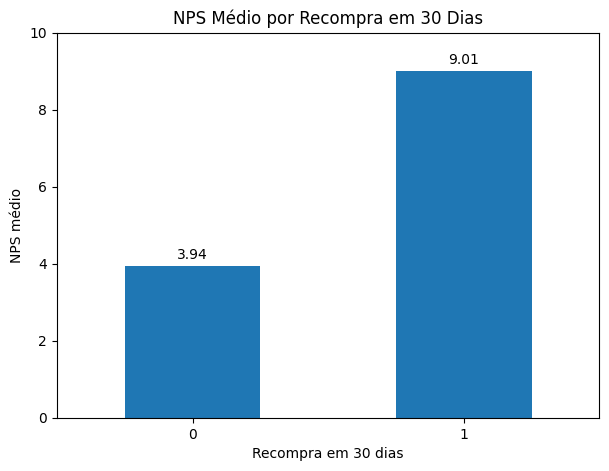

In [54]:
nps_recompra = df.groupby("repeat_purchase_30d")["nps_score"].mean()

plt.figure(figsize=(7, 5))
ax = nps_recompra.plot(kind="bar")

plt.title("NPS Médio por Recompra em 30 Dias")
plt.xlabel("Recompra em 30 dias")
plt.ylabel("NPS médio")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.ylim(0, 10)

plt.show()

Clientes que recompraram em até 30 dias apresentam NPS médio muito superior aos que não recompraram.

Essa relação deve ser interpretada com cuidado: a recompra provavelmente é consequência de uma experiência positiva, e não necessariamente a causa do NPS alto.

### 11.2 NPS médio por região

In [55]:
regiao_resumo = df.groupby("customer_region").agg(
    quantidade_clientes=("nps_score", "size"),
    nps_medio=("nps_score", "mean")
).sort_values("nps_medio")

regiao_resumo

,quantidade_clientes,nps_medio
customer_region,,
Centro-Oeste,468,4.209829
Sudeste,520,4.373846
Norte,506,4.382609
Nordeste,485,4.421649
Sul,521,4.490979


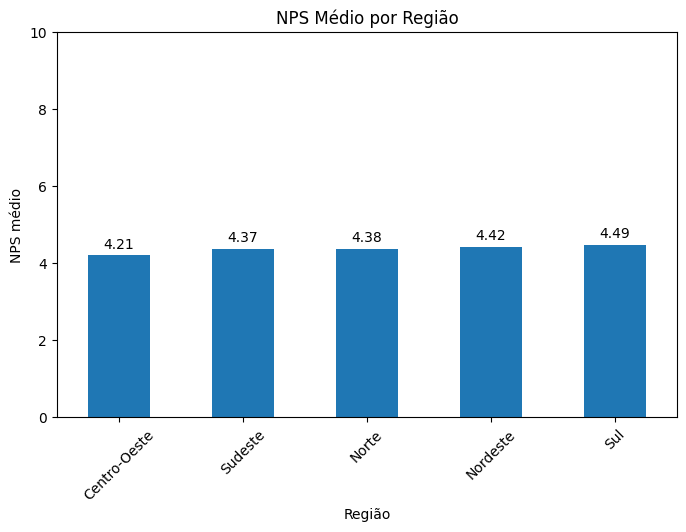

In [56]:
nps_regiao = regiao_resumo["nps_medio"]

plt.figure(figsize=(8, 5))
ax = nps_regiao.plot(kind="bar")

plt.title("NPS Médio por Região")
plt.xlabel("Região")
plt.ylabel("NPS médio")
plt.xticks(rotation=45)

ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.ylim(0, 10)

plt.show()

As diferenças de NPS médio entre regiões existem, mas são pequenas quando comparadas com fatores como atraso, reclamações e recompra.

Isso sugere que a região não parece ser o principal fator explicativo da satisfação na base analisada.

### 11.3 NPS médio por faixa etária

In [57]:
# Criando faixas de idade para facilitar a análise

df["faixa_idade"] = pd.cut(
    df["customer_age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

idade_resumo = df.groupby("faixa_idade").agg(
    quantidade_clientes=("nps_score", "size"),
    nps_medio=("nps_score", "mean")
)

idade_resumo

/tmp/ipykernel_66352/519806137.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  idade_resumo = df.groupby("faixa_idade").agg(


,quantidade_clientes,nps_medio
faixa_idade,,
18-25,389,4.476607
26-35,465,4.562151
36-45,517,4.120116
46-55,468,4.413675
56-65,476,4.265336
66+,185,4.636216


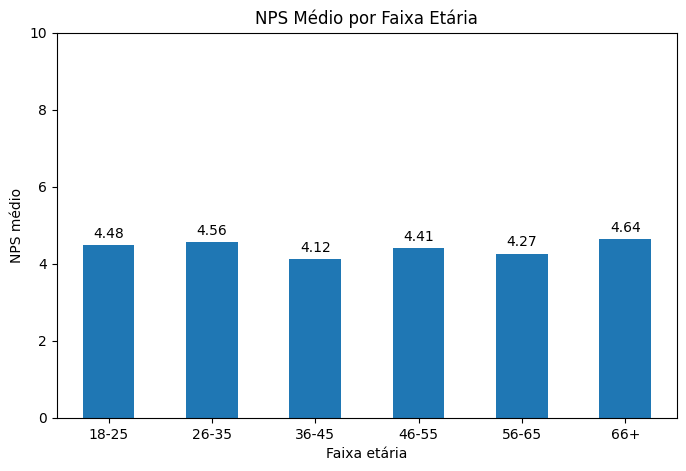

In [58]:
nps_idade = idade_resumo["nps_medio"]

plt.figure(figsize=(8, 5))
ax = nps_idade.plot(kind="bar")

plt.title("NPS Médio por Faixa Etária")
plt.xlabel("Faixa etária")
plt.ylabel("NPS médio")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.ylim(0, 10)

plt.show()

A faixa etária apresenta alguma variação no NPS médio, mas a diferença não é tão forte quanto a observada em variáveis de experiência.

Assim, idade pode ser analisada como segmentação, mas não parece ser o principal fator de satisfação.

### 11.4 NPS médio por tempo de relacionamento

In [59]:
# Criando faixas de tempo de relacionamento

df["faixa_tempo_cliente"] = pd.cut(
    df["customer_tenure_months"],
    bins=[-1, 6, 12, 24, 60, 120],
    labels=["0-6 meses", "7-12 meses", "13-24 meses", "25-60 meses", "61-120 meses"]
)

tempo_resumo = df.groupby("faixa_tempo_cliente").agg(
    quantidade_clientes=("nps_score", "size"),
    nps_medio=("nps_score", "mean")
)

tempo_resumo

/tmp/ipykernel_66352/3201331859.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tempo_resumo = df.groupby("faixa_tempo_cliente").agg(


,quantidade_clientes,nps_medio
faixa_tempo_cliente,,
0-6 meses,122,4.170492
7-12 meses,120,4.120000
13-24 meses,247,4.653036
25-60 meses,721,4.347989
61-120 meses,1290,4.386899


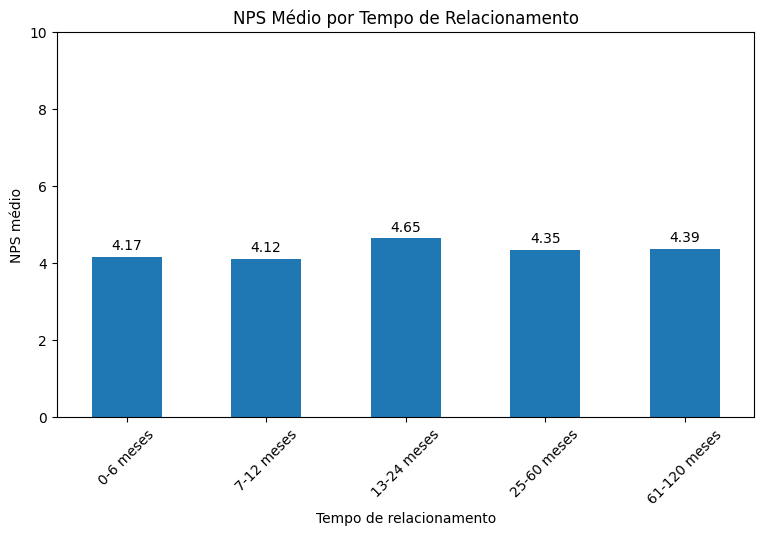

In [60]:
nps_tempo = tempo_resumo["nps_medio"]

plt.figure(figsize=(9, 5))
ax = nps_tempo.plot(kind="bar")

plt.title("NPS Médio por Tempo de Relacionamento")
plt.xlabel("Tempo de relacionamento")
plt.ylabel("NPS médio")
plt.xticks(rotation=45)

ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
plt.ylim(0, 10)

plt.show()

Clientes com diferentes tempos de relacionamento apresentam variações moderadas no NPS médio.

A análise sugere que o perfil com NPS mais alto ou mais baixo está menos relacionado a características demográficas e mais relacionado à experiência recebida.

### Conclusão sobre perfil de cliente

Clientes com NPS mais alto tendem a ser aqueles que:

- recompraram em até 30 dias;
- tiveram menor atraso na entrega;
- registraram menos reclamações;
- precisaram de menos contatos com atendimento;
- tiveram maior CSAT interno.

Clientes com NPS mais baixo tendem a ser aqueles que:

- não recompraram;
- sofreram maior atraso;
- registraram mais reclamações;
- precisaram acionar mais o atendimento;
- tiveram menor CSAT interno.

Portanto, nesta base, a satisfação parece ser mais influenciada pela qualidade da experiência do que por características como idade ou região.

## 12. Conclusões finais e recomendações de negócio

A análise exploratória mostrou que a satisfação dos clientes está fortemente associada à experiência pós-compra.

### Principais achados

1. O NPS geral da base é negativo, aproximadamente **-66**, indicando predominância de detratores.
2. Os fatores mais associados à menor satisfação são atraso na entrega, reclamações, contatos com atendimento e tempo de resolução.
3. Clientes detratores apresentam piores indicadores de experiência pós-compra.
4. Existem pontos de ruptura importantes: atraso entre **2 e 3 dias** e acúmulo de **3 ou mais reclamações**.
5. Clientes que recompram em até 30 dias apresentam NPS médio muito mais alto, indicando relação entre satisfação e fidelização.
6. Características como região, idade e tempo de relacionamento apresentam diferenças menores do que variáveis ligadas à experiência.

### Recomendações de negócio

Com base nos resultados, a empresa deveria priorizar:

- reduzir atrasos na entrega;
- monitorar clientes com 1 ou 2 dias de atraso antes que se tornem detratores;
- reduzir a quantidade de reclamações recorrentes;
- agir de forma proativa quando o cliente acumular 2 reclamações;
- diminuir a necessidade de múltiplos contatos com atendimento;
- reduzir o tempo de resolução de problemas;
- acompanhar CSAT e NPS de forma integrada;
- usar recompra em 30 dias como indicador complementar de fidelização.

### Observação final

Esta análise é exploratória. Portanto, os resultados indicam associações entre variáveis, mas não provam causalidade. Para confirmar relações causais ou prever clientes detratores, seria necessário avançar para etapas posteriores, como modelagem preditiva ou experimentos controlados.


# Apêndice: Preparação do Ambiente

In [1]:
#Clonando repositório
!git clone https://github.com/OPthyago/TECH-CHALLENGE-FASE-1.git

Cloning into 'TECH-CHALLENGE-FASE-1'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 64 (delta 1), reused 5 (delta 0), pack-reused 49 (from 1)
Receiving objects: 100% (64/64), 1.13 MiB | 8.15 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [14]:
#Entrando na pasta do challenge
%cd TECH-CHALLENGE-FASE-1

/content/TECH-CHALLENGE-FASE-1


In [15]:
#listar Branches disponiveis
!git branch -a

* andre
  main
  remotes/origin/HEAD -> origin/main
  remotes/origin/andre
  remotes/origin/fernanda
  remotes/origin/isabella
  remotes/origin/main
  remotes/origin/nicolly
  remotes/origin/thyago


In [16]:
#  Conectando na branch que desejo usar.
!git checkout andre

Already on 'andre'
Your branch is up to date with 'origin/andre'.


In [17]:
#Atualizando arquivos da branch
!git pull origin andre

remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 607.10 KiB | 2.06 MiB/s, done.
From https://github.com/OPthyago/TECH-CHALLENGE-FASE-1
 * branch            andre      -> FETCH_HEAD
   8c695a7..61f31ec  andre      -> origin/andre
Updating 8c695a7..61f31ec
Fast-forward
 notebooks/TechChallenge.ipynb | 1016 +++++++++++++++++++++++++++++++++++++----
 1 file changed, 925 insertions(+), 91 deletions(-)
